In [1]:
#Kutubxonalarni chaqirib olamiz
import pandas as pd
import numpy as np

In [2]:
#datasetni yuklab olamiz
df = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/ML/refs/heads/main/housing_LR.csv', index_col=0)
df.head()

,district,rooms,size,level,max_levels,price
0,Юнусабадский,3,57.0,4,4,52000.0
1,Яккасарайский,2,52.0,4,5,56000.0
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0


# Ustunlar ta'rifi
- `location` - sotilayotgan uy manzili
- `district` - uy joylashgan tuman
- `rooms` - xonalar soni
- `size` - uy maydoni (kv.m)
- `level` - uy

In [3]:
#Tumanlar bo'yicha datasetdagi uylarning soni
df['district'].value_counts()

,count
district,
Чиланзарский,1616
Мирзо-Улугбекский,1342
Учтепинский,872
Юнусабадский,847
Мирабадский,717
Яккасарайский,628
Яшнободский,456
Шайхантахурский,356
Олмазорский,262


In [4]:
#Chilonzorni tanlab olamiz
housing = df[df['district'] == 'Чиланзарский']
housing.head()

,district,rooms,size,level,max_levels,price
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0
5,Чиланзарский,1,28.0,1,4,25500.0
6,Чиланзарский,1,30.0,2,4,21200.0


In [5]:
#narx uchun qaysi ustun tasiri kuchli aniqlab olamiz
housing.corrwith(housing['price'], numeric_only=True)

,0
rooms,0.703835
size,0.843639
level,0.138780
max_levels,0.340015
price,1.000000


In [6]:
#Numpy array qivolamiz
x = housing['size'].to_numpy()
y = housing['price'].to_numpy()

##Chiziqli bog'liqlikni tekshiramiz

In [7]:
#Vizualizatsiya uchun kutubxonalarni chaqirib olamiz
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

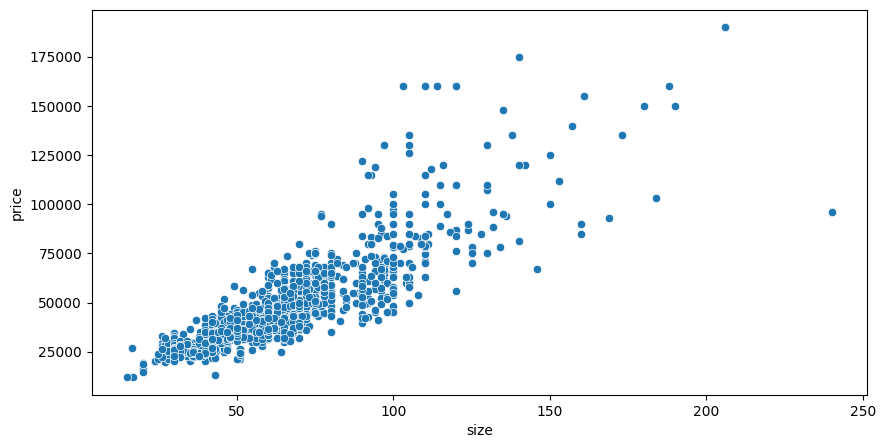

In [8]:
#Size bilan narx o'rtasidagi chiziqli bog'liqlikni ko'ramiz
plt.figure(figsize=(10, 5))
sns.scatterplot(data=housing, x='size', y='price')
plt.show()

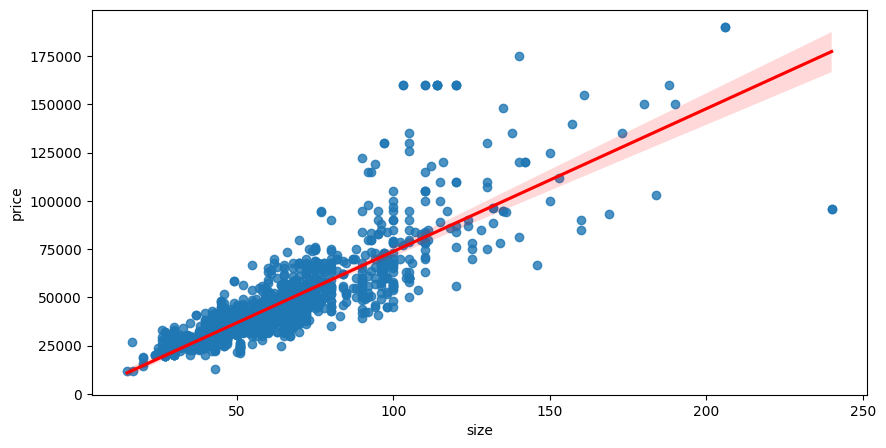

In [9]:
#chiziq bilan yaqqol bilinadi
plt.figure(figsize=(10, 5))
sns.regplot(data=housing, x='size', y='price', line_kws={'color':'red'})
plt.show()

## 1-Vazifa
Vazifamiz yuqoridagi `X` va `y` o'zgaruvchilardan quyidagi formuladan foydalangan xolda $\theta_0$ va $\theta_1$ koeffisientlarni hisoblash.

![Imgur](https://i.imgur.com/zZoXZxI.png)

Bu yerda $\tilde{x}$ - `X` ustun uchun o'rtracha qiymat,  $\tilde{y}$ - `y` ustun uchun o'rtracha qiymat

In [11]:
x_mean = x.mean()
y_mean = y.mean()

In [15]:
theta1 = sum((x-x_mean)*(y-y_mean))/sum((x-x_mean)**2)
print(f'theta1 = {theta1}')

theta1 = 740.0264822713287


In [16]:
theta0 = y_mean - theta1 * x_mean
print(f'theta0 = {theta0}')

theta0 = -195.94911352690542


## 2-Vazifa
`X` dan bir nechta tasodifiy qiymatlarni ajratib olib va ularga mos keluvchi `y` ni yuqoridagi koeffisientlar yordamida hisoblab ko'ramiz.

![Imgur](https://i.imgur.com/iT5tffj.png)

In [18]:
x_test = housing.sample(10, random_state=42)['size']
x_test

,size
392,54.0
6641,42.0
4251,36.0
5161,60.0
4157,48.0
5662,68.0
7182,38.0
1245,65.0
4736,52.0
938,44.0


In [19]:
y_test = housing.sample(10, random_state=42)['price']
y_test

,price
392,37500.0
6641,26500.0
4251,25500.0
5161,39000.0
4157,32500.0
5662,34500.0
7182,22700.0
1245,47000.0
4736,37900.0
938,36000.0


In [20]:
x_test = x_test.to_numpy()
y_test = y_test.to_numpy()

In [21]:
y_predict = theta0 + theta1 * x_test
print(f'y_predict = {y_predict}')

y_predict = [39765.48092912 30885.16314187 26445.00424824 44205.63982275
 35325.3220355  50125.85168092 27925.05721278 47905.77223411
 38285.42796458 32365.21610641]


## 3-Vazifa

Hisoblangan va asl qiymtlar o'rtasidagi RMSE (root mean square error), MAE (mean absolute error) hisoblang.

![Imgur](https://i.imgur.com/GJH9CGy.png)

![Imgur](https://i.imgur.com/aXL9iWa.png)

In [22]:
# MAE
MAE = np.sum(np.absolute(y_predict-y_test))/len(y_test)
print(f"MAE = {MAE}")

MAE = 4140.35031634715


In [23]:
# RMSE
RMSE = np.sqrt(np.sum((y_predict-y_test)**2)/len(y_test))
print(f"RMSE = {RMSE}")

RMSE = 5882.051673173715


Scikit-learn yordamida LR

In [25]:
#Qancha malumot borligini korb olamiz
housing.shape

(1616, 6)

Malumot kamligi uchun 10 % ni test uchun olamiz

In [28]:
# train va test uchun
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.10, random_state=42)

Linear Regression ML

In [29]:
#Linear Regression chaqirib olamiz
from sklearn.linear_model import LinearRegression

In [31]:
model_LR = LinearRegression()

In [32]:
x_train = np.asanyarray(train_set[['size']])
y_train = np.asanyarray(train_set[['price']])


In [33]:
#Modelni o'qitib olamiz
model_LR.fit(x_train, y_train)

LinearRegression()

In [36]:
theta1 = model_LR.coef_[0][0]
print(theta1)

732.7784051414766


In [38]:
theta0 = model_LR.intercept_[0]
print(theta0)

106.31843170110369


$\theta_0$ va $\theta_1$ qiymatlari yordamida to'g'ri chiziq chizamiz

Text(0, 0.5, 'Price')

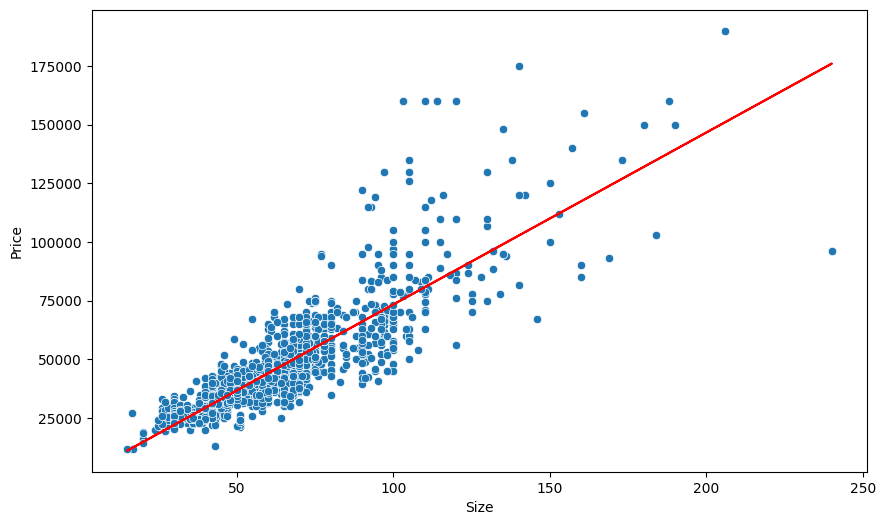

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=housing, x='size', y='price')
plt.plot(x_train, theta1*x_train + theta0, '-r')
plt.xlabel("Size")
plt.ylabel("Price")

Modelni baholaymiz

In [40]:
#Test set
x_test = np.asanyarray(test_set[['size']])
y_test = np.asanyarray(test_set[['price']])

In [41]:
y_predict = model_LR.predict(x_test)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [43]:
MAE = mean_absolute_error(y_test, y_predict)
RMSE = np.sqrt(mean_squared_error(y_test, y_predict))

print(f'MAE = {MAE}')
print(f'RMSE = {RMSE}')

MAE = 7269.709648262382
RMSE = 12734.803748258666
